In [1]:
# Import required libraries
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read in the insurance dataset
insurance = pd.read_csv("insurance.csv")

In [3]:
insurance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [4]:
# Check out the insurance dataset
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
# Turn all categories into numbers
df = pd.get_dummies(insurance)
df.head() # view the converted columns

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [6]:
# Create X & y values
X = df.drop("charges", axis=1)
y = df["charges"]

In [8]:
# View features
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,False,True
1,18,33.770,1,False,True,True,False,False,False,True,False
2,28,33.000,3,False,True,True,False,False,False,True,False
3,33,22.705,0,False,True,True,False,False,True,False,False
4,32,28.880,0,False,True,True,False,False,True,False,False


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[1:10,:]

array([[-1.50996545,  0.5096211 , -0.07876719, -0.98959079,  0.98959079,
         0.5074631 , -0.5074631 , -0.56526686, -0.56641788,  1.63579466,
        -0.56641788],
       [-0.79795355,  0.38330685,  1.58092576, -0.98959079,  0.98959079,
         0.5074631 , -0.5074631 , -0.56526686, -0.56641788,  1.63579466,
        -0.56641788],
       [-0.4419476 , -1.30553108, -0.90861367, -0.98959079,  0.98959079,
         0.5074631 , -0.5074631 , -0.56526686,  1.76548098, -0.61132367,
        -0.56641788],
       [-0.51314879, -0.29255641, -0.90861367, -0.98959079,  0.98959079,
         0.5074631 , -0.5074631 , -0.56526686,  1.76548098, -0.61132367,
        -0.56641788],
       [-0.58434998, -0.80765608, -0.90861367,  1.0105187 , -1.0105187 ,
         0.5074631 , -0.5074631 , -0.56526686, -0.56641788,  1.63579466,
        -0.56641788],
       [ 0.48366788,  0.45548642, -0.07876719,  1.0105187 , -1.0105187 ,
         0.5074631 , -0.5074631 , -0.56526686, -0.56641788,  1.63579466,
        -0.566

In [10]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [12]:
# Create training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42) # set random state for reproducible splits

In [13]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1070, 11) (268, 11) (1070,) (268,)


#### Build the model

In [14]:
from keras.models import Sequential
from keras.layers import Dense

In [15]:
# Set random seed
#tf.random.set_seed(42)

# Create a new model (same as model_2)
insurance_model = Sequential([
  Dense(12,input_dim=11),
  Dense(8),
  Dense(1)
])

# Compile the model
insurance_model.compile(loss='mse',
                        optimizer='adam',
                        metrics=['mae'])

C:\Users\Lenovo\anaconda4\Lib\site-packages\keras\src\layers\core\dense.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
# Fit the model
history = insurance_model.fit(X_train, y_train, epochs=300)

Epoch 1/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 314445120.0000 - mae: 13256.0107   
Epoch 2/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 347328768.0000 - mae: 13918.4004
Epoch 3/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 326095584.0000 - mae: 13482.2451
Epoch 4/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 324699680.0000 - mae: 13430.7705
Epoch 5/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 333354336.0000 - mae: 13502.7441
Epoch 6/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 307384128.0000 - mae: 13088.1846
Epoch 7/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 292729344.0000 - mae: 12611.0166
Epoch 8/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 342773632.0000 - mae: 13706.2686
Epoch 9/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 338790656.0000 - mae: 13649.2949
Epoch 10/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 326773568.0000 - mae: 13468.0508
Epoch 11/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 360103232.0000

In [16]:
mae_values = insurance_model.history.history['mae']
len(mae_values)

AttributeError: 'Sequential' object has no attribute 'history'

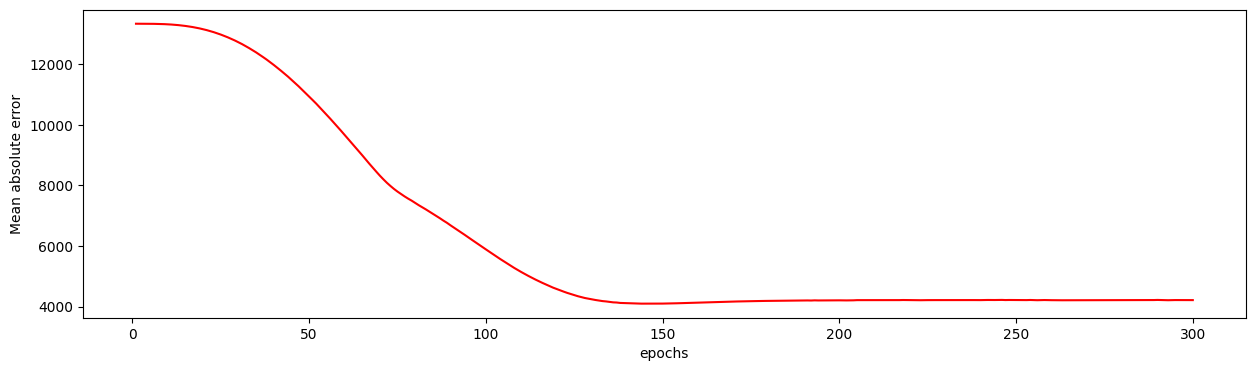

In [18]:
# see the error how it is reduced to minimum times for epoch=5
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 4))
#plt.scatter(range(1,301),mae_values)
plt.plot(range(1,301),mae_values,color='red')
plt.ylabel("Mean absolute error")
plt.xlabel("epochs")
plt.show()

# prompt: can you give some more optimizer function names for the above code

- tf.keras.optimizers.RMSprop()
- tf.keras.optimizers.Adadelta()
- tf.keras.optimizers.Adagrad()
- tf.keras.optimizers.Adamax()
- tf.keras.optimizers.Nadam()
- tf.keras.optimizers.Ftrl()
